# Mask R-CNN Object Detection for MOT16 (A100 Optimized)

Mask R-CNN on MOT16. A100 w/ AMP, BS=8, warmup + cosine LR.

In [1]:
import os
import random
import math
import time
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import cv2
import matplotlib.pyplot as plt

import torch
import torchvision
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import functional as F
import torchvision.transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torch.amp import autocast, GradScaler

# A100 Optimizations
torch.backends.cudnn.benchmark = True

SEED = 9776
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('Torch:', torch.__version__)
print('Torchvision:', torchvision.__version__)


Device: cuda
Torch: 2.10.0+cu128
Torchvision: 0.25.0+cu128


## 1. Setup & Configuration

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DATA_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/MOT16")
TRAIN_ROOT = DATA_ROOT / "train"
TEST_ROOT = DATA_ROOT / "test"

SAVE_DIR = Path('/content/drive/MyDrive/Colab Notebooks/MOT16-model')
SAVE_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = SAVE_DIR / 'maskrcnn_mot16_checkpoint.pth'
BEST_MODEL_PATH = SAVE_DIR / 'maskrcnn_mot16_best.pth'

# Hyperparameters
EPOCHS = 40
WARMUP_EPOCHS = 4
PATIENCE = 6
BASE_LR = 3e-3           # Heads LR
BACKBONE_LR = 3e-4       # Backbone LR (10x smaller)
MAX_GRAD_NORM = 1.0
BATCH_SIZE = 8
NUM_WORKERS = 8
PIN_MEMORY = True


Mounted at /content/drive


## 2. Transforms & Dataset

In [9]:
MOT_COLUMNS = [
    "frame", "track_id", "bb_left", "bb_top", "bb_width", "bb_height",
    "conf", "class_id", "visibility"
]

def parse_gt_file(gt_file):
    df = pd.read_csv(gt_file, header=None, names=MOT_COLUMNS)
    df = df[df['class_id'] == 1].copy()
    df['sequence'] = gt_file.parent.parent.name
    df['image_id'] = df.apply(lambda row: f"{row['sequence']}/{int(row['frame']):06d}", axis=1)
    df['x1'] = df['bb_left'].astype(float)
    df['y1'] = df['bb_top'].astype(float)
    df['x2'] = (df['bb_left'] + df['bb_width']).astype(float)
    df['y2'] = (df['bb_top'] + df['bb_height']).astype(float)
    return df

def load_train_annotations(train_root):
    all_dfs = []
    for seq_dir in sorted(train_root.iterdir()):
        if not seq_dir.is_dir():
            continue
        gt_file = seq_dir / 'gt' / 'gt.txt'
        if gt_file.exists():
            all_dfs.append(parse_gt_file(gt_file))
    return pd.concat(all_dfs, ignore_index=True)

class ComposeTransforms:
    def __init__(self, transforms_list):
        self.transforms_list = transforms_list
    def __call__(self, image, target):
        for t in self.transforms_list:
            image, target = t(image, target)
        return image, target

class ToTensorTransform:
    def __call__(self, image, target):
        return F.to_tensor(image), target

class RandomHorizontalFlipTransform:
    def __init__(self, p=0.5):
        self.p = p
    def __call__(self, image, target):
        if random.random() < self.p:
            width = image.shape[-1] if isinstance(image, torch.Tensor) else image.size[0]
            image = F.hflip(image)
            if target is not None and 'boxes' in target:
                boxes = target['boxes'].clone()
                boxes[:, [0, 2]] = width - boxes[:, [2, 0]]
                target['boxes'] = boxes
        return image, target

class ResizeTransform:
    def __init__(self, size=(384, 640)):
        self.size = size
    def __call__(self, image, target):
        old_w, old_h = image.size
        new_h, new_w = self.size
        image = F.resize(image, self.size)
        if target is not None and 'boxes' in target:
            boxes = target["boxes"].clone()
            boxes[:, [0, 2]] = boxes[:, [0, 2]] * (new_w / old_w)
            boxes[:, [1, 3]] = boxes[:, [1, 3]] * (new_h / old_h)
            target["boxes"] = boxes
        return image, target

class ColorJitterTransform:
    def __init__(self, brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1):
        self.jitter = T.ColorJitter(brightness, contrast, saturation, hue)
    def __call__(self, image, target):
        image = self.jitter(image)
        return image, target

class RandomScaleTransform:
    def __init__(self, scale_range=(0.8, 1.2)):
        self.scale_range = scale_range
    def __call__(self, image, target):
        scale = random.uniform(*self.scale_range)
        old_w, old_h = image.size
        new_w, new_h = int(old_w * scale), int(old_h * scale)
        image = F.resize(image, (new_h, new_w))
        if target is not None and 'boxes' in target:
            boxes = target["boxes"].clone()
            boxes *= scale
            target["boxes"] = boxes
        return image, target

def get_transforms(train=True):
    t = []
    if train:
        t.append(RandomScaleTransform(scale_range=(0.8, 1.2)))
    t.append(ResizeTransform((384, 640)))
    if train:
        t.append(ColorJitterTransform())
    t.append(ToTensorTransform())
    if train:
        t.append(RandomHorizontalFlipTransform(p=0.5))
    return ComposeTransforms(t)

def collate_fn(batch):
    return tuple(zip(*batch))


In [ ]:
class MOTDetectionDataset(Dataset):
    def __init__(self, annotations_df, train_root, transforms=None):
        self.df = annotations_df.copy()
        self.train_root = Path(train_root)
        self.transforms = transforms
        self.image_ids = sorted(self.df['image_id'].unique().tolist())

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        seq_name, frame_name = image_id.split('/')
        img_path = self.train_root / seq_name / 'img1' / f'{frame_name}.jpg'

        records = self.df[self.df['image_id'] == image_id]
        boxes = records[['x1', 'y1', 'x2', 'y2']].values.astype(np.float32)
        labels = np.ones((len(records),), dtype=np.int64)
        areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        iscrowd = np.zeros((len(records),), dtype=np.int64)

        if not img_path.exists():
            raise FileNotFoundError(f"Image not found: {img_path}")

        image = Image.open(img_path).convert('RGB')

        target = {
            'boxes': torch.as_tensor(boxes, dtype=torch.float32),
            'labels': torch.as_tensor(labels, dtype=torch.int64),
            'image_id': torch.tensor([idx]),
            'area': torch.as_tensor(areas, dtype=torch.float32),
            'iscrowd': torch.as_tensor(iscrowd, dtype=torch.int64),
            'track_ids': torch.as_tensor(records['track_id'].values, dtype=torch.int64),
        }

        if self.transforms is not None:
            image, target = self.transforms(image, target)

        # Generate box-shaped masks from bounding boxes 
        h, w = image.shape[-2:]
        num_objs = len(target['boxes'])
        masks = torch.zeros((num_objs, h, w), dtype=torch.uint8)
        for i in range(num_objs):
            x1, y1, x2, y2 = target['boxes'][i].int().tolist()
            # Clamp coordinates to valid image dimensions
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)
            masks[i, y1:y2, x1:x2] = 1
        target['masks'] = masks

        return image, target

train_df = load_train_annotations(TRAIN_ROOT)

image_ids = sorted(train_df['image_id'].unique().tolist())
random.seed(SEED)
random.shuffle(image_ids)
val_size = int(len(image_ids) * 0.2)
val_ids = image_ids[:val_size]
train_ids = image_ids[val_size:]

train_df_split = train_df[train_df['image_id'].isin(train_ids)].copy()
val_df_split = train_df[train_df['image_id'].isin(val_ids)].copy()

train_dataset = MOTDetectionDataset(train_df_split, TRAIN_ROOT, transforms=get_transforms(train=True))
val_dataset = MOTDetectionDataset(val_df_split, TRAIN_ROOT, transforms=get_transforms(train=False))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn,
                          pin_memory=PIN_MEMORY, persistent_workers=True)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, collate_fn=collate_fn,
                        pin_memory=PIN_MEMORY, persistent_workers=True)
print(f"Data loaded. Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")

Data loaded. Train size: 4253, Val size: 1063


## 3. Mask R-CNN Model Definition

In [3]:
def get_model(num_classes):
    weights = torchvision.models.detection.MaskRCNN_ResNet50_FPN_Weights.DEFAULT
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(
        weights=weights,
        min_size=384,
        max_size=640
    )

    # Replace box predictor for 2 classes (background + pedestrian)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # Freeze mask head — reuse COCO person masks
    for p in model.roi_heads.mask_predictor.parameters():
        p.requires_grad = False

    return model

model = get_model(num_classes=2)
model.to(device)
print("Model ready.")


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 245MB/s]


Model ready.


## 4. Optimizer, AMP, & LR Scheduler

In [5]:
from tqdm.auto import tqdm

# Diff LR: lower for backbone
backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
head_params = (
    [p for p in model.rpn.parameters() if p.requires_grad] +
    [p for p in model.roi_heads.parameters() if p.requires_grad]
)

params = [
    {"params": backbone_params, "initial_lr": BACKBONE_LR, "lr": BACKBONE_LR},
    {"params": head_params, "initial_lr": BASE_LR, "lr": BASE_LR},
]

optimizer = torch.optim.AdamW(params, weight_decay=1e-4)
scaler = GradScaler('cuda')  # For Mixed Precision (AMP)

def adjust_lr(optimizer, epoch):
    
    if epoch < WARMUP_EPOCHS:
        scale = (epoch + 1) / WARMUP_EPOCHS
    else:
        progress = (epoch - WARMUP_EPOCHS) / max(EPOCHS - WARMUP_EPOCHS, 1)
        scale = 0.5 * (1 + math.cos(math.pi * progress))

    for pg in optimizer.param_groups:
        pg['lr'] = pg['initial_lr'] * scale

def train_one_epoch(model, loader, optimizer, scaler, device, epoch):
    model.train()
    running_loss = 0.0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1} Training", leave=False)
    for step, (images, targets) in enumerate(pbar, 1):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        with autocast('cuda'):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        scaler.scale(losses).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        scaler.step(optimizer)
        scaler.update()

        running_loss += losses.item()

        if step % 100 == 0:
            detail = ", ".join(f"{k}: {v.item():.4f}" for k, v in loss_dict.items())
            pbar.set_postfix_str(f"Loss: {losses.item():.4f} ({detail})")

    return running_loss / max(len(loader), 1)

def compute_val_loss(model, loader, device):
    model.train() # Need to be in train mode to compute losses
    # Freeze BN stats
    for m in model.modules():
        if isinstance(m, torch.nn.BatchNorm2d):
            m.eval()

    running_loss = 0.0
    with torch.no_grad():
        for images, targets in tqdm(loader, desc="Validation", leave=False):
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            with autocast('cuda'):
                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())
            running_loss += losses.item()
    return running_loss / max(len(loader), 1)

def plot_history(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Train Loss', color='blue')
    plt.plot(history['val_loss'], label='Val Loss', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Mask R-CNN Training Curves')
    plt.legend()
    plt.grid(True)
    plt.show()


## 5. Training Loop with Checkpointing

Loading checkpoint from /content/drive/MyDrive/Colab Notebooks/MOT16-model/maskrcnn_mot16_checkpoint.pth
Resuming from epoch 41 with best_val=0.3783


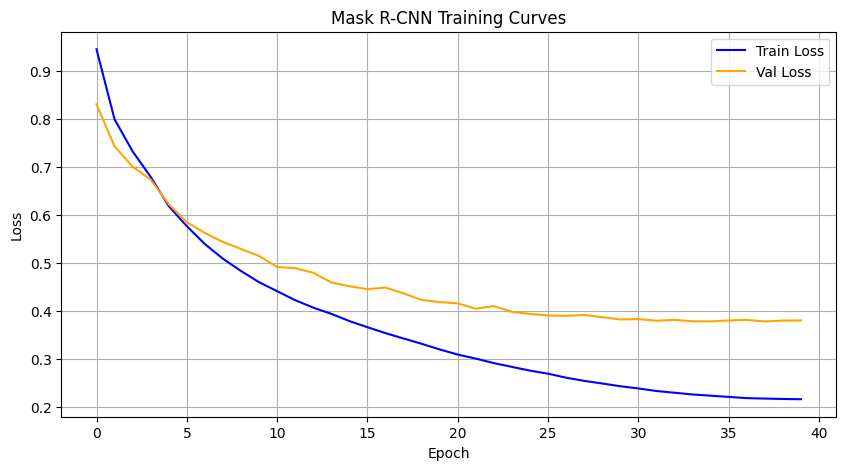

In [6]:
start_epoch = 0
best_val = float('inf')
epochs_without_improvement = 0
history = {'train_loss': [], 'val_loss': []}

# Resume if checkpoint exists
if CHECKPOINT_PATH.exists():
    print(f"Loading checkpoint from {CHECKPOINT_PATH}")
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scaler.load_state_dict(ckpt['scaler'])
    start_epoch = ckpt['epoch'] + 1
    best_val = ckpt['best_val']
    history = ckpt.get('history', {'train_loss': [], 'val_loss': []})
    epochs_without_improvement = ckpt.get('epochs_without_improvement', 0)
    print(f"Resuming from epoch {start_epoch+1} with best_val={best_val:.4f}")

for epoch in range(start_epoch, EPOCHS):
    start_time = time.time()

    # Adjust learning rate
    adjust_lr(optimizer, epoch)
    current_lr_heads = optimizer.param_groups[1]['lr']
    current_lr_backbone = optimizer.param_groups[0]['lr']
    print(f"\nEpoch {epoch+1}/{EPOCHS} | LR Heads: {current_lr_heads:.6f} | LR Backbone: {current_lr_backbone:.6f}")

    train_loss = train_one_epoch(model, train_loader, optimizer, scaler, device, epoch)
    val_loss = compute_val_loss(model, val_loader, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    # Save latest checkpoint
    torch.save({
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scaler': scaler.state_dict(),
        'epoch': epoch,
        'best_val': best_val,
        'history': history,
        'epochs_without_improvement': epochs_without_improvement
    }, CHECKPOINT_PATH)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1} Summary: Train Loss={train_loss:.4f} | Val Loss={val_loss:.4f} | Time={elapsed:.1f}s")

    if val_loss < best_val:
        best_val = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"🌟 New best model saved (val_loss: {best_val:.4f})")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s).")
        if epochs_without_improvement >= PATIENCE:
            print(f"🛑 Early stopping triggered!")
            break

plot_history(history)


## 6. Evaluation & Visualizations

Loaded trained weights. Retained COCO pretrained mask head and predictor for real person silhouettes!


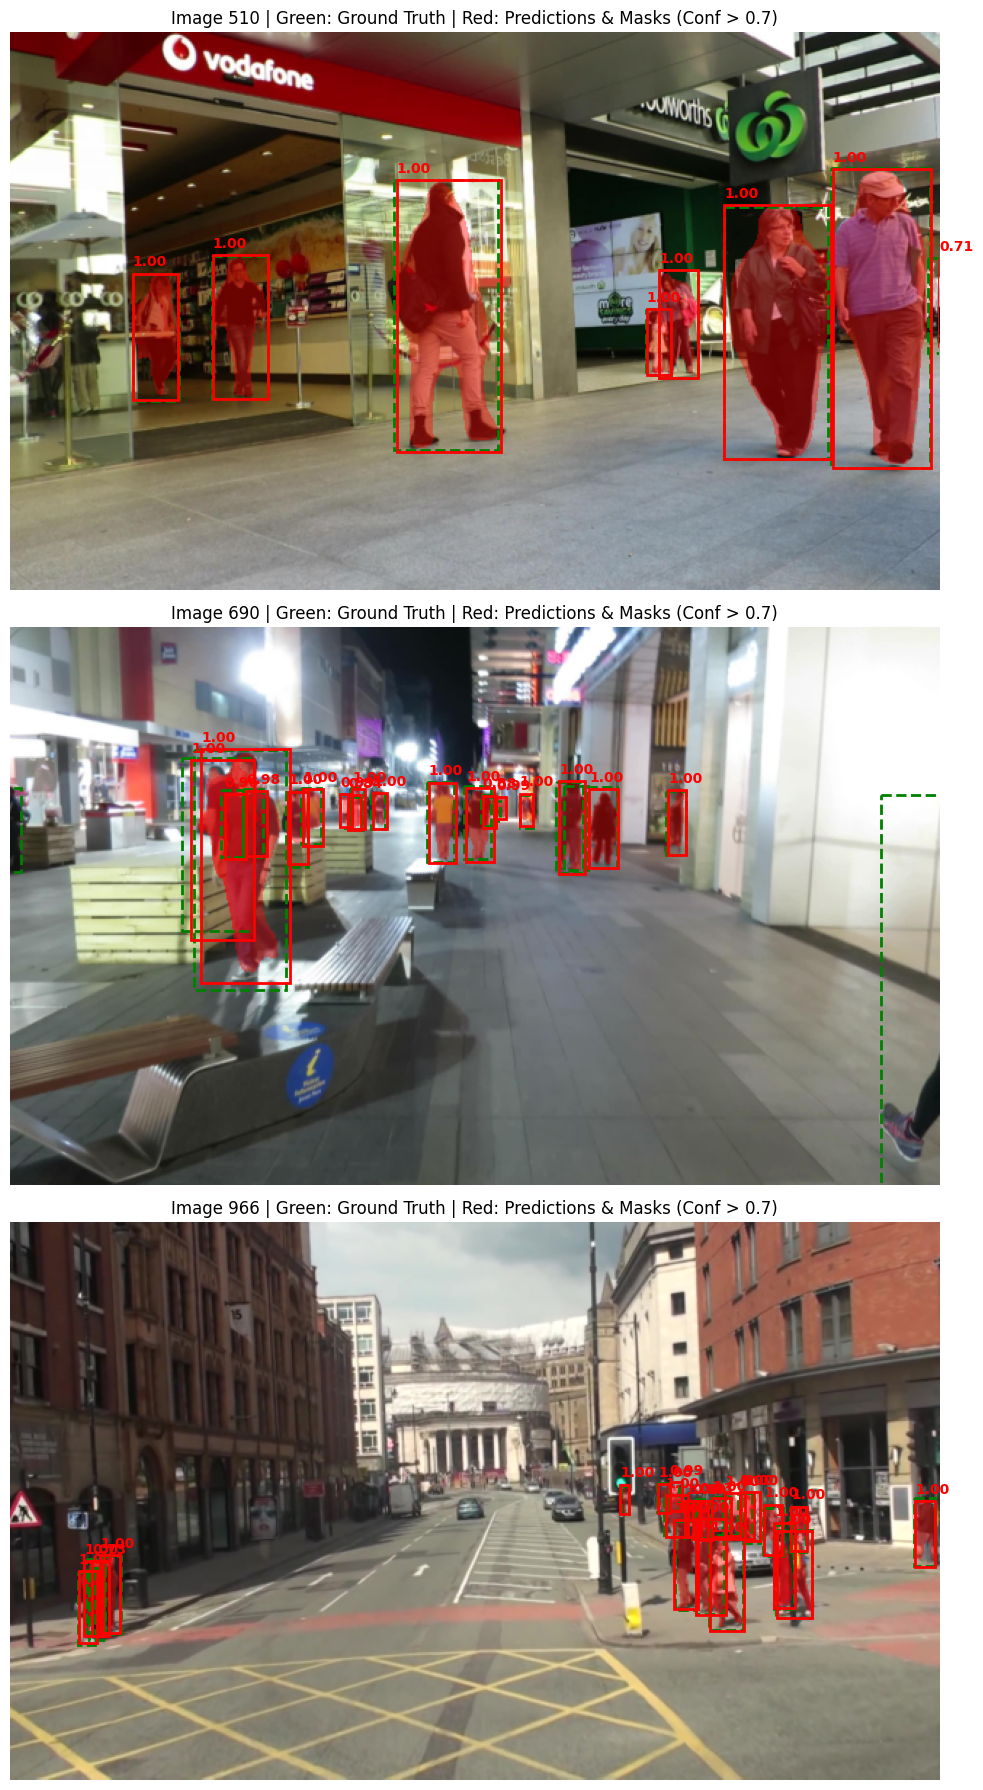

In [15]:
import matplotlib.patches as patches

def visualize_predictions(model, dataset, device, num_images=3, threshold=0.6):
    model.eval()
    indices = random.sample(range(len(dataset)), num_images)

    fig, axes = plt.subplots(num_images, 1, figsize=(12, 6 * num_images))
    if num_images == 1: axes = [axes]

    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, target = dataset[idx]
            img_tensor = image.to(device).unsqueeze(0)

            predictions = model(img_tensor)[0]

            # Convert image to numpy for plotting
            img_np = image.permute(1, 2, 0).cpu().numpy()
            img_np = np.clip(img_np, 0, 1)

            ax = axes[i]
            ax.axis('off')

            boxes = predictions['boxes'].cpu().numpy()
            scores = predictions['scores'].cpu().numpy()
            masks = predictions['masks'].cpu().numpy()

            # Ground truth boxes
            gt_boxes = target['boxes'].numpy()
            for box in gt_boxes:
                rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                         linewidth=2, edgecolor='g', facecolor='none', linestyle='--')
                ax.add_patch(rect)

            ax.imshow(img_np)

            for j, (box, score, mask) in enumerate(zip(boxes, scores, masks)):
                if score >= threshold:
                    # Bounding Box (Edges only, no fill)
                    rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                             linewidth=2, edgecolor='r', facecolor='none')
                    ax.add_patch(rect)

                    # Confidence score text
                    ax.text(box[0], box[1] - 5, f"{score:.2f}", color='r', fontsize=10, weight='bold')

                    # Overlay Mask: use RGBA to keep background completely transparent
                    mask_img = mask[0] > 0.5
                    rgba_mask = np.zeros((img_np.shape[0], img_np.shape[1], 4))
                    rgba_mask[..., 0] = 1.0  # Red channel
                    rgba_mask[..., 3] = mask_img * 0.4  # Alpha channel: 0.4 for mask, 0 for background
                    ax.imshow(rgba_mask)

            ax.set_title(f"Image {idx} | Green: Ground Truth | Red: Predictions & Masks (Conf > {threshold})")

    plt.tight_layout()
    plt.show()

# Load best model
if BEST_MODEL_PATH.exists():
    # Build from COCO weights
    inference_model = torchvision.models.detection.maskrcnn_resnet50_fpn(
        weights=torchvision.models.detection.MaskRCNN_ResNet50_FPN_Weights.DEFAULT,
        min_size=384, max_size=640
    )
    # Replace box predictor for 2 classes
    in_features = inference_model.roi_heads.box_predictor.cls_score.in_features
    inference_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 2)

    # Load our weights, skip mask keys
    trained_state = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=True)
    filtered_state = {k: v for k, v in trained_state.items() if 'roi_heads.mask' not in k}

    missing, unexpected = inference_model.load_state_dict(filtered_state, strict=False)
    print("Loaded weights (mask head from COCO)")

    inference_model.to(device)
    inference_model.eval()
    model = inference_model

visualize_predictions(model, val_dataset, device, num_images=3, threshold=0.7)


In [ ]:

!pip install torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 67.0 MB/s eta 0:00:00


In [ ]:
try:
    from torchmetrics.detection.mean_ap import MeanAveragePrecision

    def evaluate_map(model, loader, device):
        model.eval()
        metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox')

        with torch.no_grad():
            for images, targets in tqdm(loader, desc="Evaluating mAP"):
                images = [img.to(device) for img in images]

                # Convert targets to CPU for metric computation
                target_metrics = []
                for t in targets:
                    target_metrics.append({
                        'boxes': t['boxes'].cpu(),
                        'labels': t['labels'].cpu(),
                    })

                # Get predictions
                preds = model(images)
                pred_metrics = []
                for p in preds:
                    pred_metrics.append({
                        'boxes': p['boxes'].cpu(),
                        'scores': p['scores'].cpu(),
                        'labels': p['labels'].cpu(),
                    })

                metric.update(pred_metrics, target_metrics)

        results = metric.compute()
        print(f"\nEvaluation Results (COCO mAP):")
        print(f"mAP: {results['map']:.4f}")
        print(f"mAP@50: {results['map_50']:.4f}")
        print(f"mAP@75: {results['map_75']:.4f}")
        return results

    # Uncomment to evaluate the best model
    if BEST_MODEL_PATH.exists():
        trained_state = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=True)
        # Filter out mask predictor to avoid shape mismatch with the 91 class model in memory
        filtered_state = {k: v for k, v in trained_state.items() if 'mask_predictor' not in k}
        model.load_state_dict(filtered_state, strict=False)
        model.to(device)
        evaluate_map(model, val_loader, device)
except ImportError:
    print("Install torchmetrics for mAP evaluation: !pip install torchmetrics")


Evaluating mAP:   0%|          | 0/133 [00:00<?, ?it/s]


Evaluation Results (COCO mAP):
mAP: 0.7067
mAP@50: 0.8698
mAP@75: 0.7578


In [ ]:
def create_tracking_video(model, seq_dir, output_path, device, threshold=0.7):
    model.eval()
    img_dir = Path(seq_dir) / 'img1'
    if not img_dir.exists():
        print(f"Directory {img_dir} does not exist.")
        return

    img_paths = sorted(list(img_dir.glob('*.jpg')))
    if not img_paths:
        print(f"No images found in {img_dir}.")
        return

    # Read first image to get dimensions
    first_img = cv2.imread(str(img_paths[0]))
    h, w, _ = first_img.shape

    # Initialize VideoWriter
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(str(output_path), fourcc, 30.0, (w, h))

    print(f"Generating video for {Path(seq_dir).name} ({len(img_paths)} frames)...")

    with torch.no_grad():
        for img_path in tqdm(img_paths, desc="Processing Frames"):
            img_cv = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

            # Transform to tensor
            img_tensor = F.to_tensor(img_rgb).to(device).unsqueeze(0)

            # Inference
            predictions = model(img_tensor)[0]
            boxes = predictions['boxes'].cpu().numpy()
            scores = predictions['scores'].cpu().numpy()
            masks = predictions['masks'].cpu().numpy()

            # Draw bounding boxes (no fill) and masks
            for box, score, mask in zip(boxes, scores, masks):
                if score >= threshold:
                    x1, y1, x2, y2 = map(int, box)

                    # Bounding Box
                    cv2.rectangle(img_cv, (x1, y1), (x2, y2), (0, 0, 255), 2)

                    # Confidence score text
                    cv2.putText(img_cv, f"{score:.2f}", (x1, y1 - 5),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

                    # Overlay Mask
                    mask_img = mask[0] > 0.5
                    color = np.array([0, 0, 255], dtype=np.float32)  # BGR for red
                    alpha = 0.4

                    # Blend mask
                    roi = img_cv[mask_img]
                    if len(roi) > 0:
                        img_cv[mask_img] = (roi * (1 - alpha) + color * alpha).astype(np.uint8)

            out.write(img_cv)

    out.release()
    print(f"Video saved to {output_path}")

# Let's generate a video for the first sequence found in TRAIN_ROOT
available_seqs = [d for d in TRAIN_ROOT.iterdir() if d.is_dir()]
if available_seqs:
    sample_seq = available_seqs[0]
    output_video_path = SAVE_DIR / f"{sample_seq.name}_tracking.mp4"
    create_tracking_video(model, sample_seq, output_video_path, device, threshold=0.7)
else:
    print("No sequence directories found to create video.")


Generating video for MOT16-13 (750 frames)...


Processing Frames:   0%|          | 0/750 [00:00<?, ?it/s]

Video saved to /content/drive/MyDrive/Colab Notebooks/MOT16-model/MOT16-13_tracking.mp4


## 7. AUC & Precision-Recall Curves
PR AUC instead of ROC AUC (background is infinite). Match preds to GT with IoU.

Evaluating AUC:   0%|          | 0/133 [00:00<?, ?it/s]

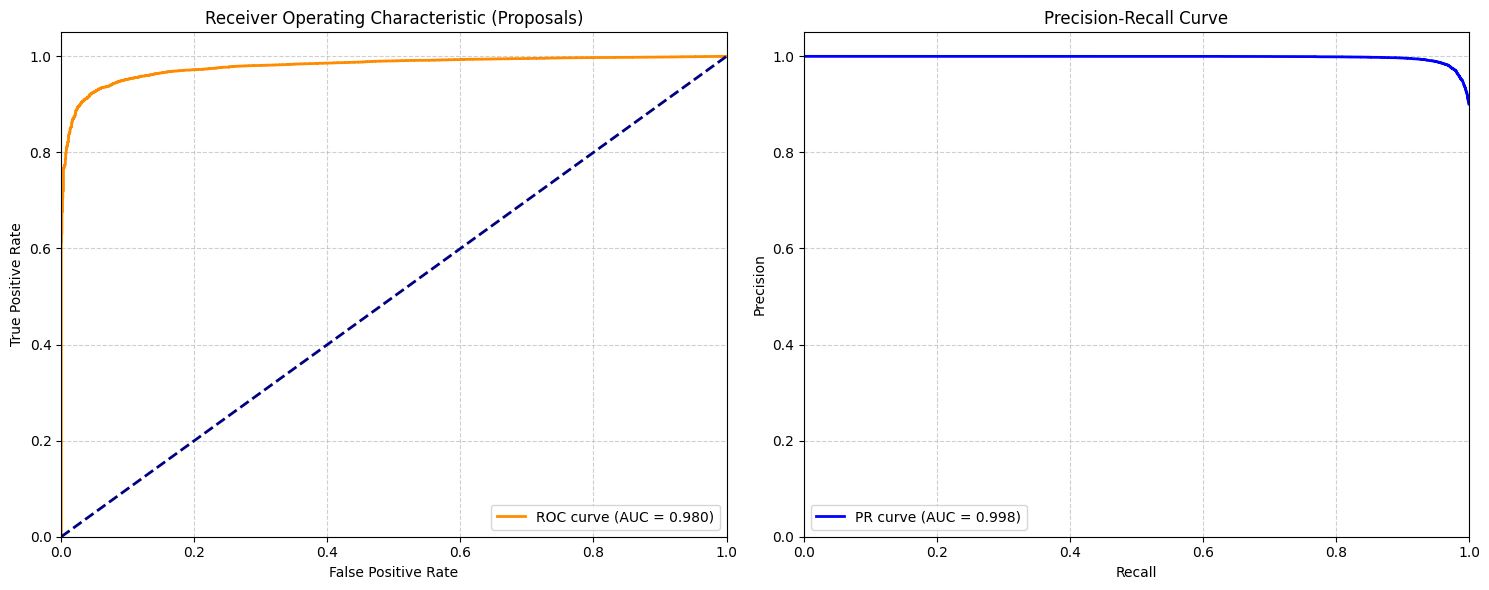

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import torchvision.ops as ops

def plot_auc_curves(model, loader, device, iou_threshold=0.5):
    model.eval()
    all_scores = []
    all_matches = []  # 1 if True Positive, 0 if False Positive

    with torch.no_grad():
        for images, targets in tqdm(loader, desc="Evaluating AUC"):
            images = [img.to(device) for img in images]
            preds = model(images)

            for target, pred in zip(targets, preds):
                gt_boxes = target['boxes'].to(device)
                pred_boxes = pred['boxes']
                scores = pred['scores']

                if len(pred_boxes) == 0:
                    continue
                if len(gt_boxes) == 0:
                    all_scores.extend(scores.cpu().tolist())
                    all_matches.extend([0] * len(scores))
                    continue

                # Calculate Intersection over Union (IoU)
                ious = ops.box_iou(pred_boxes, gt_boxes)
                max_ious, max_idx = ious.max(dim=1)

                matched_gts = set()

                for i, (iou, gt_idx) in enumerate(zip(max_ious, max_idx)):
                    gt_idx = gt_idx.item()
                    # Match if IoU > threshold and GT hasn't been matched yet
                    if iou >= iou_threshold and gt_idx not in matched_gts:
                        all_matches.append(1)
                        matched_gts.add(gt_idx)
                    else:
                        all_matches.append(0)
                    all_scores.append(scores[i].item())

    y_true = np.array(all_matches)
    y_scores = np.array(all_scores)

    if len(y_true) == 0:
        print("No predictions found to evaluate.")
        return

    # Calculate ROC metrics
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    # Calculate Precision-Recall metrics
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_auc = average_precision_score(y_true, y_scores)

    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # ROC Curve
    ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('Receiver Operating Characteristic (Proposals)')
    ax1.legend(loc="lower right")
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Precision-Recall Curve
    ax2.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curve')
    ax2.legend(loc="lower left")
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Run the evaluation on the validation set
plot_auc_curves(model, val_loader, device, iou_threshold=0.5)


Evaluating Thresholds:   0%|          | 0/133 [00:00<?, ?it/s]

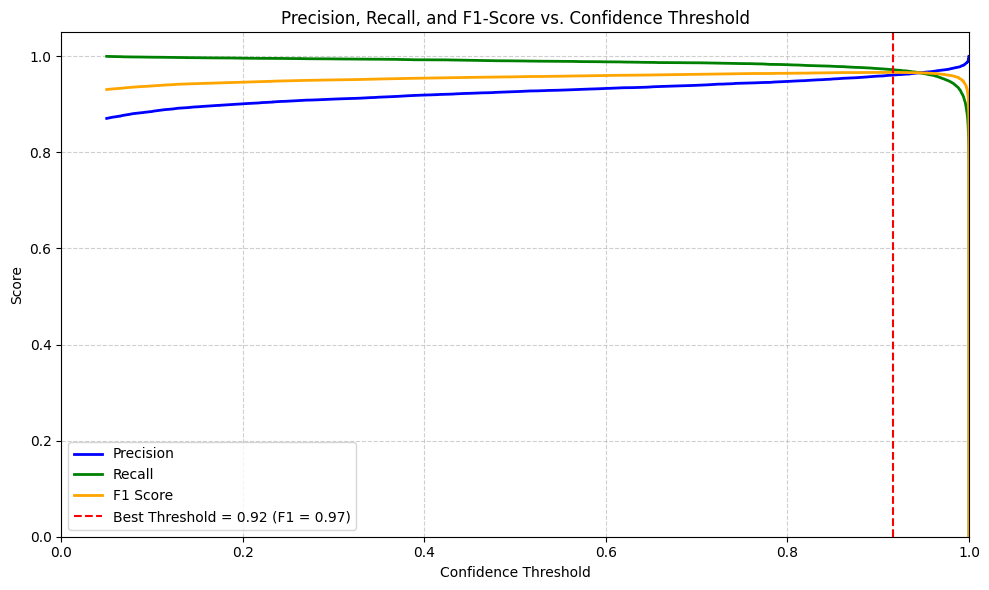

In [ ]:
def plot_metrics_vs_threshold(model, loader, device, iou_threshold=0.5):
    model.eval()
    all_scores = []
    all_matches = []

    with torch.no_grad():
        for images, targets in tqdm(loader, desc="Evaluating Thresholds"):
            images = [img.to(device) for img in images]
            preds = model(images)

            for target, pred in zip(targets, preds):
                gt_boxes = target['boxes'].to(device)
                pred_boxes = pred['boxes']
                scores = pred['scores']

                if len(pred_boxes) == 0:
                    continue
                if len(gt_boxes) == 0:
                    all_scores.extend(scores.cpu().tolist())
                    all_matches.extend([0] * len(scores))
                    continue

                # Calculate IoU
                ious = ops.box_iou(pred_boxes, gt_boxes)
                max_ious, max_idx = ious.max(dim=1)

                matched_gts = set()

                for i, (iou, gt_idx) in enumerate(zip(max_ious, max_idx)):
                    gt_idx = gt_idx.item()
                    # Match if IoU > threshold and GT hasn't been matched yet
                    if iou >= iou_threshold and gt_idx not in matched_gts:
                        all_matches.append(1)
                        matched_gts.add(gt_idx)
                    else:
                        all_matches.append(0)
                    all_scores.append(scores[i].item())

    y_true = np.array(all_matches)
    y_scores = np.array(all_scores)

    if len(y_true) == 0:
        print("No predictions found to evaluate.")
        return

    # Calculate Precision and Recall across all thresholds
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

    # thresholds array has length len(precision) - 1, append 1.0 to match shapes
    thresholds = np.append(thresholds, 1.0)

    # Calculate F1 Score for each threshold
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, precision, label='Precision', color='blue', lw=2)
    plt.plot(thresholds, recall, label='Recall', color='green', lw=2)
    plt.plot(thresholds, f1_scores, label='F1 Score', color='orange', lw=2)

    # Highlight the best threshold based on F1 Score
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    plt.axvline(x=best_thresh, color='red', linestyle='--', label=f'Best Threshold = {best_thresh:.2f} (F1 = {best_f1:.2f})')

    plt.xlabel('Confidence Threshold')
    plt.ylabel('Score')
    plt.title('Precision, Recall, and F1-Score vs. Confidence Threshold')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.legend(loc="lower left")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Run the evaluation on the validation set
plot_metrics_vs_threshold(model, val_loader, device, iou_threshold=0.6)
